# 11. Проект. Модель для показа рекламных предложений

В этом проекте вам необходимо реализовать мониторинг модели с помощью Prometheus и Grafana. Вы можете сами выбрать решаемую задачу и датасет. Если не знаете, что выбрать, то можете остановиться на этих данных "winequality-red.csv"

Этапы, которые нужно пройти:
- Создание модели.
- Скраппинг метрик модели с помощью Prometheus.
- Подключение Prometheus к Grafana.
- Отрисовка дашборда.

С нуля писать взаимодействие между всеми этими компонентами довольно сложно. Будет очень здорово, если у вас получится отобразить хотя бы score модели на дашборде Grafana, который будет передаваться через Prometheus. 

Если же вы хотите более красочный дашборд, то можно пойти немного другим путём и использовать уже заранее созданные взаимодействия между этими компонентами в Kubernetes. Подробная инструкция https://github.com/PsychoBel/Monitoring-ML-models

### Критерии проверки
Критерий
- Создана модель - 2 балла
- Метрики модели передаются в Prometheus - 2 балла
- На дашборде отображены метрики модели - 4 балла
- Модель настроена так, что её можно дообучать - 2 балла

### Импорт библиотек

In [127]:
# pip install prometheus-client

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [268]:
import numpy as np
import pandas as pd
import plotly.express as px
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

### 1. Загрузка датасета

In [269]:
dataset = pd.read_csv('data/winequality-red.csv', sep=';')
dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### 2. Анализ данных был выполнен ранее в разделе Kernell Function. Буду использовать уже готовое решение из домашнего задания "DS-ADD-4".

### 2.1 Функция по обработке и стандартизации признаков

In [270]:
def data_pre_processing(df):
    # Сделаем целевую переменную категориальной ('bad wine': quality < 6.5 и 'good wine': quality > 6.5)
    if 'quality' in df.columns:
        df['good_wine'] = (df['quality'] >= 6.5).astype(int)
        df = df.drop(columns=['quality'])
    
    #Отношение свободного к общему SO2
    df['so2_ratio'] = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-6)
    
    # Отделяем признаки от целевой переменной
    target_col = 'good_wine'
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Масштабируем только признаки
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Собираем обратно DataFrame: признаки scaled + исходный таргет
    df_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=df.index)
    df_scaled[target_col] = y.values
    
    return df_scaled

### 2.2 Проверим и применим функцию по обработке данных:

In [271]:
dataset = data_pre_processing(dataset)
dataset.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,so2_ratio,good_wine
0,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246,-0.379847,0
1,-0.298547,1.967442,-1.391472,0.043416,0.223875,0.872638,0.624363,0.028261,-0.719933,0.128950,-0.584777,-0.059300,0
2,-0.298547,1.297065,-1.186070,-0.169427,0.096353,-0.083669,0.229047,0.134264,-0.331177,-0.048089,-0.584777,-0.675494,0
3,1.654856,-1.384443,1.484154,-0.453218,-0.264960,0.107592,0.411500,0.664277,-0.979104,-0.461180,-0.584777,-0.639594,0
4,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246,-0.379847,0


### 2.3 Разделим на train и test выборки

In [272]:
X = dataset.drop('good_wine', axis = 1)
y = dataset['good_wine']

### 3. Реализация стримингового прочтения файлов. Попробуем воссоздать поток реальных данных. Для этого разобьем данные на батчи и будем их по порядку считывать.

In [273]:
def streaming_reading(X_train, y_train, batch_size=400):
    X = []
    y = []
    current_line = 0
    train_data, train_label = shuffle(X_train, y_train, random_state=0)
    train_data = train_data.to_numpy()
    for row, target in zip(train_data, train_label):
        X.append(row)
        y.append(target)

        current_line += 1
        if current_line >= batch_size:
            X, y = np.array(X), np.array(y)
            yield X, y
            X, y = [], []
            current_line = 0

### 4. Экспорт метрик модели в Prometheus

In [274]:
from prometheus_client import start_http_server, Gauge

# Запускаем HTTP-сервер и регистрируем Gauge только один раз за время жизни kernel,
# иначе повторный запуск ячейки вызовет OSError (порт занят) или DuplicateTimeseries
if 'metric_accuracy' not in globals():
    try:
        start_http_server(8001)
    except OSError:
        pass

    metric_accuracy = Gauge('model_accuracy', 'Accuracy текущей модели на holdout-батче')
    metric_precision = Gauge('model_precision', 'Precision текущей модели на holdout-батче')
    metric_recall = Gauge('model_recall', 'Recall текущей модели на holdout-батче')
    metric_f1 = Gauge('model_f1', 'F1 текущей модели на holdout-батче')
    metric_n_estimators = Gauge('model_n_estimators', 'Количество деревьев в RandomForest')

### 5. Реализация RandomForest (инкрементальное дообучение через warm_start)

In [275]:
def IncrementalRandomForest(X, y, n_estimators_step=50, random_state=42):
    rf = RandomForestClassifier(n_estimators=0, warm_start=True, random_state=random_state)
    streaming_train_iterators = streaming_reading(X, y, batch_size=400)
    history = []

    for i, data in enumerate(streaming_train_iterators):
        X_batch = data[0]
        y_batch = data[1]
        X_train, X_test, y_train, y_test = train_test_split(X_batch, y_batch, test_size=0.1, random_state=0)
        y_train = y_train.ravel()

        # warm_start добавляет новые деревья к уже обученным на предыдущих батчах
        rf.n_estimators += n_estimators_step
        rf.fit(X_train, y_train)

        pred_test = rf.predict(X_test)
        acc = accuracy_score(y_test, pred_test)
        prec = precision_score(y_test, pred_test, zero_division=0)
        rec = recall_score(y_test, pred_test, zero_division=0)
        f1 = f1_score(y_test, pred_test, zero_division=0)
        history.append({
            'batch': i,
            'n_estimators': rf.n_estimators,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
        })

        # Передаем метрики текущего батча в Prometheus
        metric_accuracy.set(acc)
        metric_precision.set(prec)
        metric_recall.set(rec)
        metric_f1.set(f1)
        metric_n_estimators.set(rf.n_estimators)

        print("{} time".format(i))
        print('The score of the current model on the holdout batch is: accuracy=%.4f, n_estimators=%d, \n'
              % (acc, rf.n_estimators))

    return rf, pd.DataFrame(history)

### 6. Запуск обучения

In [276]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.2)
rf_model, train_history = IncrementalRandomForest(train_X, train_y)
pred_classes = rf_model.predict(test_X)
print(f'F1 score: {f1_score(test_y, pred_classes)}')
print('------------------------------------------')
print(f'Precision: {precision_score(test_y, pred_classes)}')
print('------------------------------------------')
print(f'Recall: {recall_score(test_y, pred_classes)}')

joblib.dump(rf_model, 'loan_model_homework.pkl')
rf_model = joblib.load('loan_model_homework.pkl')

0 time
The score of the current model on the holdout batch is: accuracy=0.9250, n_estimators=50, 

1 time
The score of the current model on the holdout batch is: accuracy=0.9750, n_estimators=100, 

2 time
The score of the current model on the holdout batch is: accuracy=0.9000, n_estimators=150, 

F1 score: 0.4444444444444444
------------------------------------------
Precision: 0.7142857142857143
------------------------------------------
Recall: 0.3225806451612903


c:\Users\tgorbunov\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning:

X has feature names, but RandomForestClassifier was fitted without feature names



### 7. Графики метрик по батчам обучения

In [277]:
fig_metrics = px.line(
    train_history,
    x='batch',
    y=['accuracy', 'precision', 'recall', 'f1'],
    markers=True,
    title='Метрики holdout-части батча в процессе инкрементального обучения'
)
fig_metrics.update_layout(yaxis_title='score', xaxis_title='batch', yaxis_range=[0, 1])
fig_metrics.show()

fig_n_estimators = px.line(
    train_history,
    x='batch',
    y='n_estimators',
    markers=True,
    title='Рост числа деревьев RandomForest по батчам (warm_start)'
)
fig_n_estimators.show()

### 8. Проверка что данные подхвачены Prometheus:

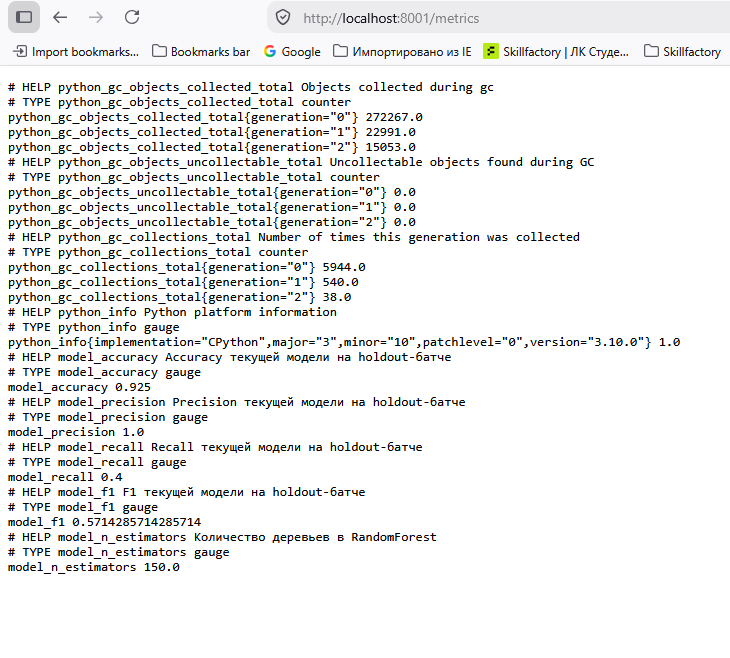

### 9. Проверка что target ml_model в статусе UP

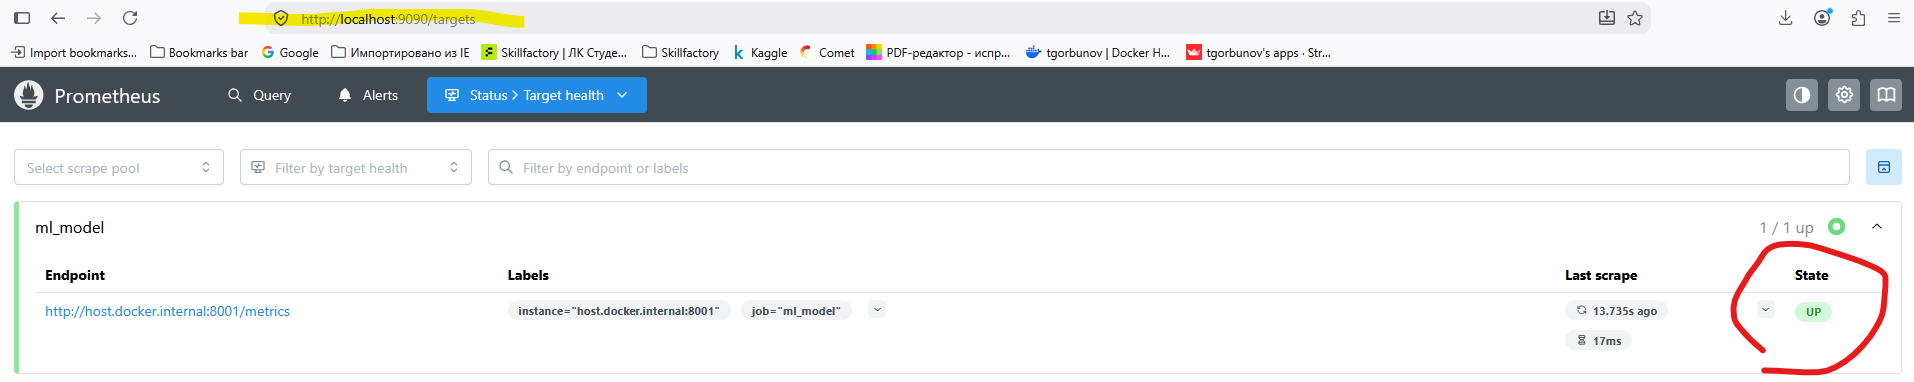

### 10. Настройка Dashboard и проверка логов по метрикам:
- Dashboard настроен
- Данные подгружаются и отображаются

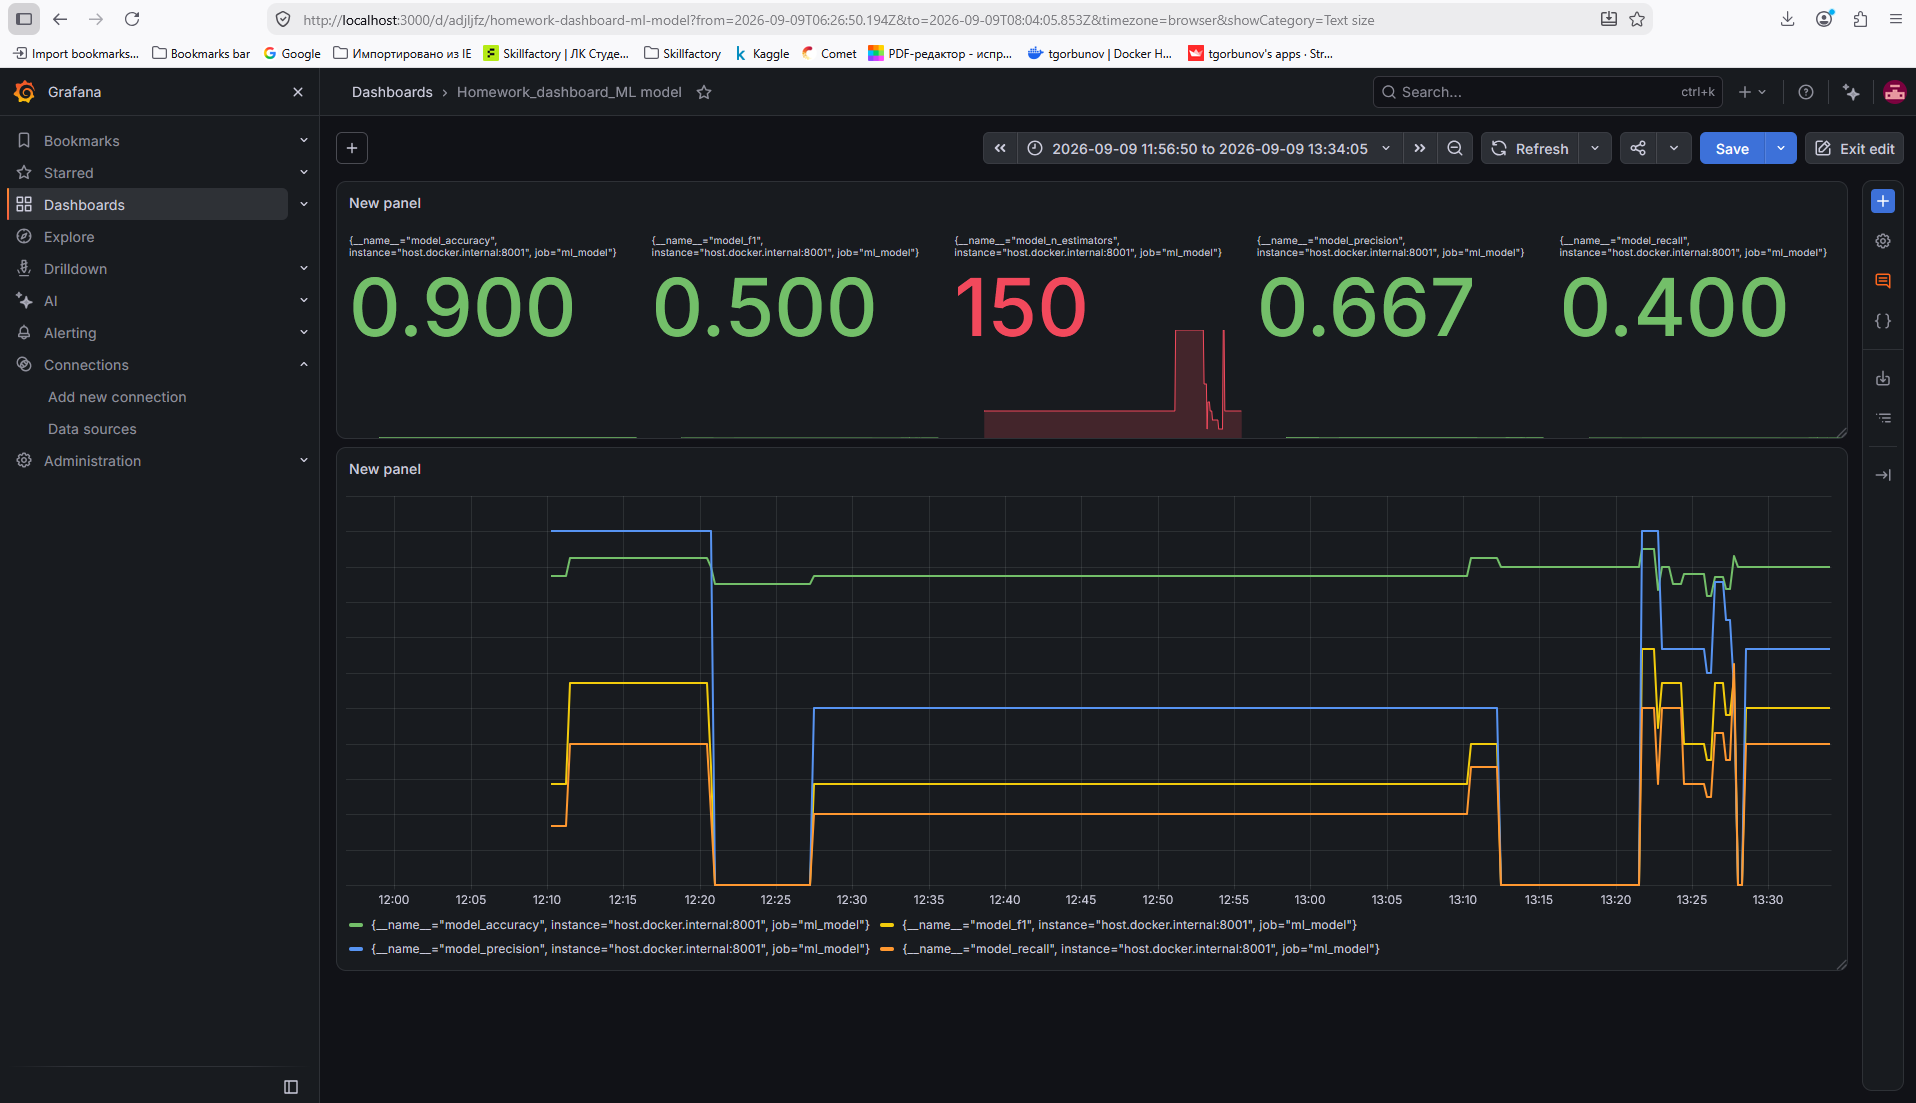

> # Вывод по работе:
> 
> - **Создана модель**: `RandomForestClassifier` для бинарной классификации качества вина на датасете 'winequality-red.csv'.
> 
> - **Модель настроена так, что её можно дообучать**: обучение реализовано инкрементально через `warm_start=True` — данные читаются потоково батчами (`streaming_reading`), и на каждом батче в модель добавляется новая порция деревьев (`n_estimators += step`) без потери уже обученных.
> 
> - Дополнительно построены графики (Plotly) динамики метрик и роста `n_estimators` по батчам прямо в ноутбуке для наглядности инкрементального обучения.
> 
> - **Метрики модели передаются в Prometheus**: с помощью `prometheus_client` подняты **Gauge**-метрики (`model_accuracy`, `model_precision`, `model_recall`, `model_f1`, `model_n_estimators`), обновляемые после каждого батча, и HTTP-эндпоинт `/metrics` (`start_http_server(8001)`), который опрашивается Prometheus согласно job `ml_model` в `prometheus.yml`.
> 
> - **На дашборде отображены метрики модели**: в Grafana настроен дашборд `Homework Dashboard ML Model`, подключённый к Prometheus как data source; на панелях отображаются accuracy/precision/recall/f1 и рост числа деревьев по батчам обучения.
